In [12]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Библиотеки загружены")
print(f"📅 Дата: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


✅ Библиотеки загружены
📅 Дата: 2026-01-23 16:29


In [13]:
# Загрузка исторических данных
df = pd.read_csv('../data/raw/astana_historical.csv')

# Конвертировать time в datetime
df['time'] = pd.to_datetime(df['time'])

# Создать колонку feels_like (приближенная формула)
# Учитываем температуру, влажность и ветер
df['feels_like'] = df['temperature'] - (0.4 * df['wind_speed']) - (0.02 * (100 - df['humidity']))

print(f"📊 Загружено {len(df)} записей")
print(f"📆 Период: {df['time'].min()} — {df['time'].max()}")
print(f"📅 Продолжительность: {(df['time'].max() - df['time'].min()).days} дней")
print(f"\n🔍 Информация о данных:")
print(df.info())


📊 Загружено 18073 записей
📆 Период: 2024-01-01 00:00:00 — 2026-01-23 00:00:00
📅 Продолжительность: 753 дней

🔍 Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18073 entries, 0 to 18072
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           18073 non-null  datetime64[ns]
 1   temperature    18073 non-null  float64       
 2   dew_point      18073 non-null  float64       
 3   humidity       18073 non-null  float64       
 4   precipitation  17522 non-null  float64       
 5   snow           0 non-null      float64       
 6   wind_deg       18073 non-null  float64       
 7   wind_speed     18073 non-null  float64       
 8   wind_gust      0 non-null      float64       
 9   pressure       18073 non-null  float64       
 10  sunshine       0 non-null      float64       
 11  weather_code   18055 non-null  float64       
 12  feels_like     18073 non-null  float64  

In [14]:
# Статистика
print("📈 Статистические показатели:")
print(df.describe())

# Показать колонки
print(f"\n📋 Доступные колонки:")
print(df.columns.tolist())


📈 Статистические показатели:
                      time   temperature     dew_point      humidity  \
count                18073  18073.000000  18073.000000  18073.000000   
mean   2025-01-11 12:00:00      5.033935     -0.686804     70.493554   
min    2024-01-01 00:00:00    -33.300000    -36.900000     15.000000   
25%    2024-07-07 06:00:00     -5.900000     -8.400000     57.000000   
50%    2025-01-11 12:00:00      5.100000     -0.200000     75.000000   
75%    2025-07-18 18:00:00     16.800000      8.900000     86.000000   
max    2026-01-23 00:00:00     35.600000     19.100000    100.000000   
std                    NaN     13.657746     11.031752     18.591216   

       precipitation  snow      wind_deg    wind_speed  wind_gust  \
count   17522.000000   0.0  18073.000000  18073.000000        0.0   
mean        0.055017   NaN    182.046644      6.483157        NaN   
min         0.000000   NaN      1.000000      0.000000        NaN   
25%         0.000000   NaN    134.000000      

In [15]:
# Первые 5 записей
print("📋 Первые 5 записей:")
df.head()


📋 Первые 5 записей:


,time,temperature,dew_point,humidity,precipitation,snow,wind_deg,wind_speed,wind_gust,pressure,sunshine,weather_code,feels_like
0,2024-01-01 00:00:00,-0.6,-2.3,88.0,0.0,NaN,201.0,13.0,NaN,1019.2,NaN,4.0,-6.04
1,2024-01-01 01:00:00,-0.3,-2.2,87.0,0.0,NaN,198.0,13.0,NaN,1018.6,NaN,4.0,-5.76
2,2024-01-01 02:00:00,-0.1,-2.0,87.0,0.0,NaN,197.0,14.8,NaN,1017.9,NaN,14.0,-6.28
3,2024-01-01 03:00:00,0.2,-1.9,86.0,0.0,NaN,195.0,16.7,NaN,1017.3,NaN,14.0,-6.76
4,2024-01-01 04:00:00,-0.1,-2.3,85.0,0.0,NaN,195.0,16.7,NaN,1017.2,NaN,14.0,-7.08


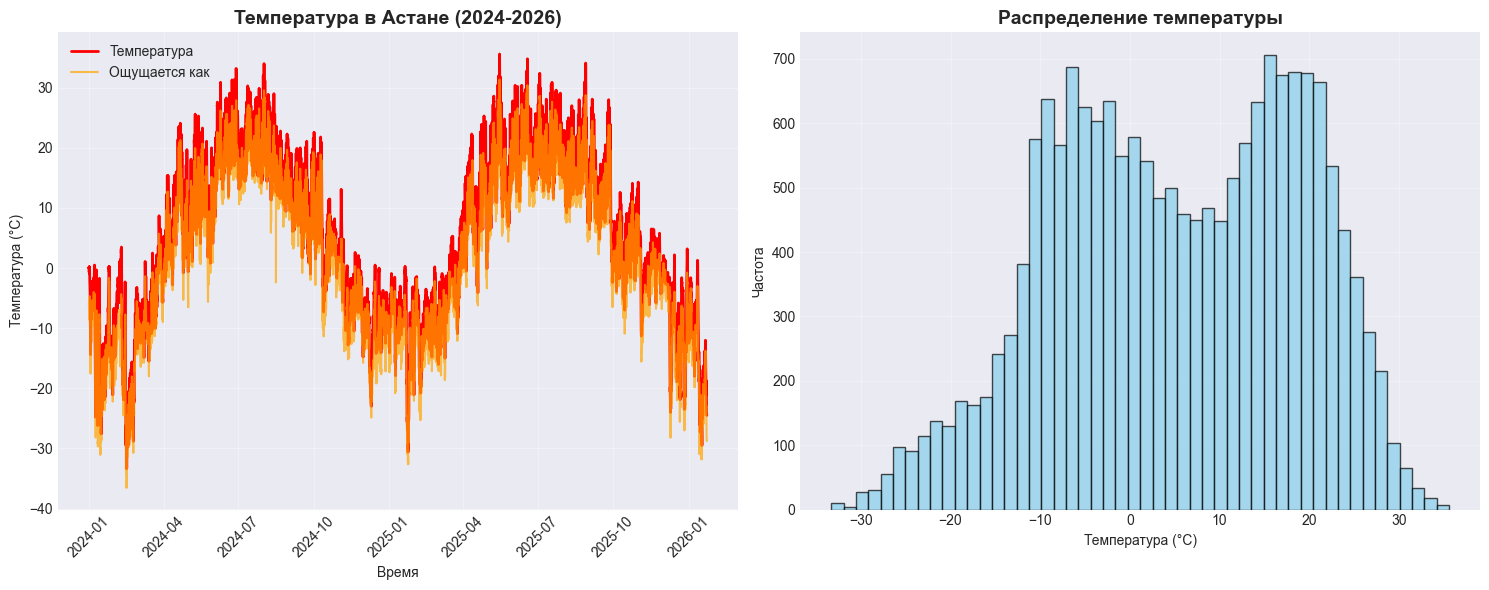

✅ График сохранён в docs/temperature_analysis.png


In [16]:
# График температуры
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(df['time'], df['temperature'], label='Температура', color='red', linewidth=2)
plt.plot(df['time'], df['feels_like'], label='Ощущается как', color='orange', alpha=0.7)
plt.xlabel('Время')
plt.ylabel('Температура (°C)')
plt.title('Температура в Астане (2024-2026)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.hist(df['temperature'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')
plt.title('Распределение температуры', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/temperature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ График сохранён в docs/temperature_analysis.png")



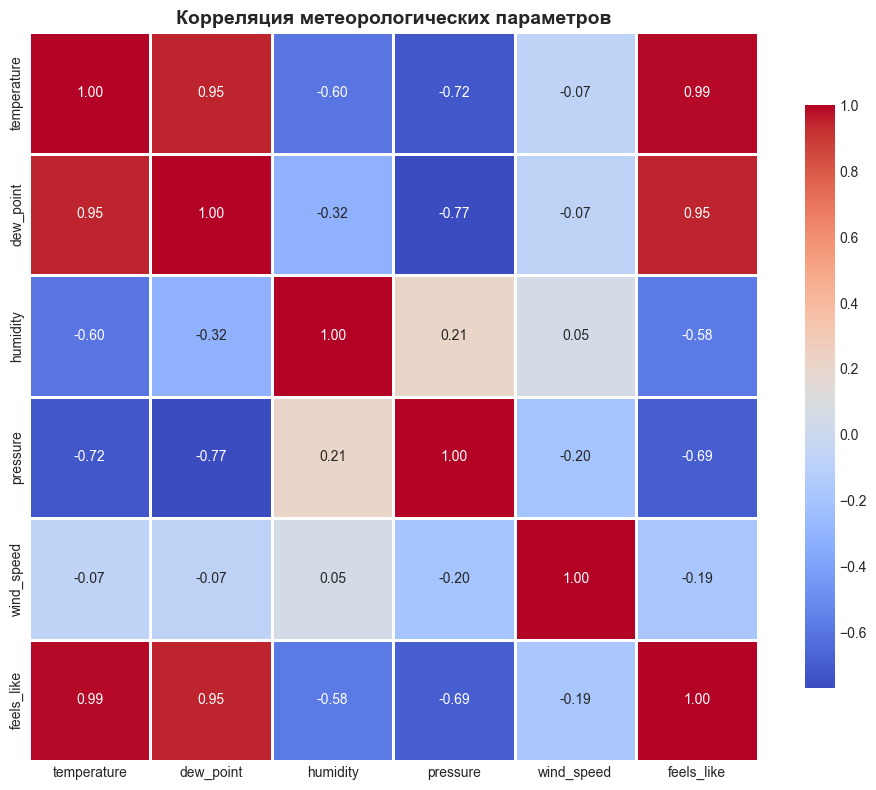

✅ Матрица корреляции сохранена


In [17]:
# Матрица корреляции
plt.figure(figsize=(10, 8))

# Выбрать только числовые колонки (которые есть в данных)
numeric_cols = ['temperature', 'dew_point', 'humidity', 
                'pressure', 'wind_speed', 'feels_like']

correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Корреляция метеорологических параметров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Матрица корреляции сохранена")



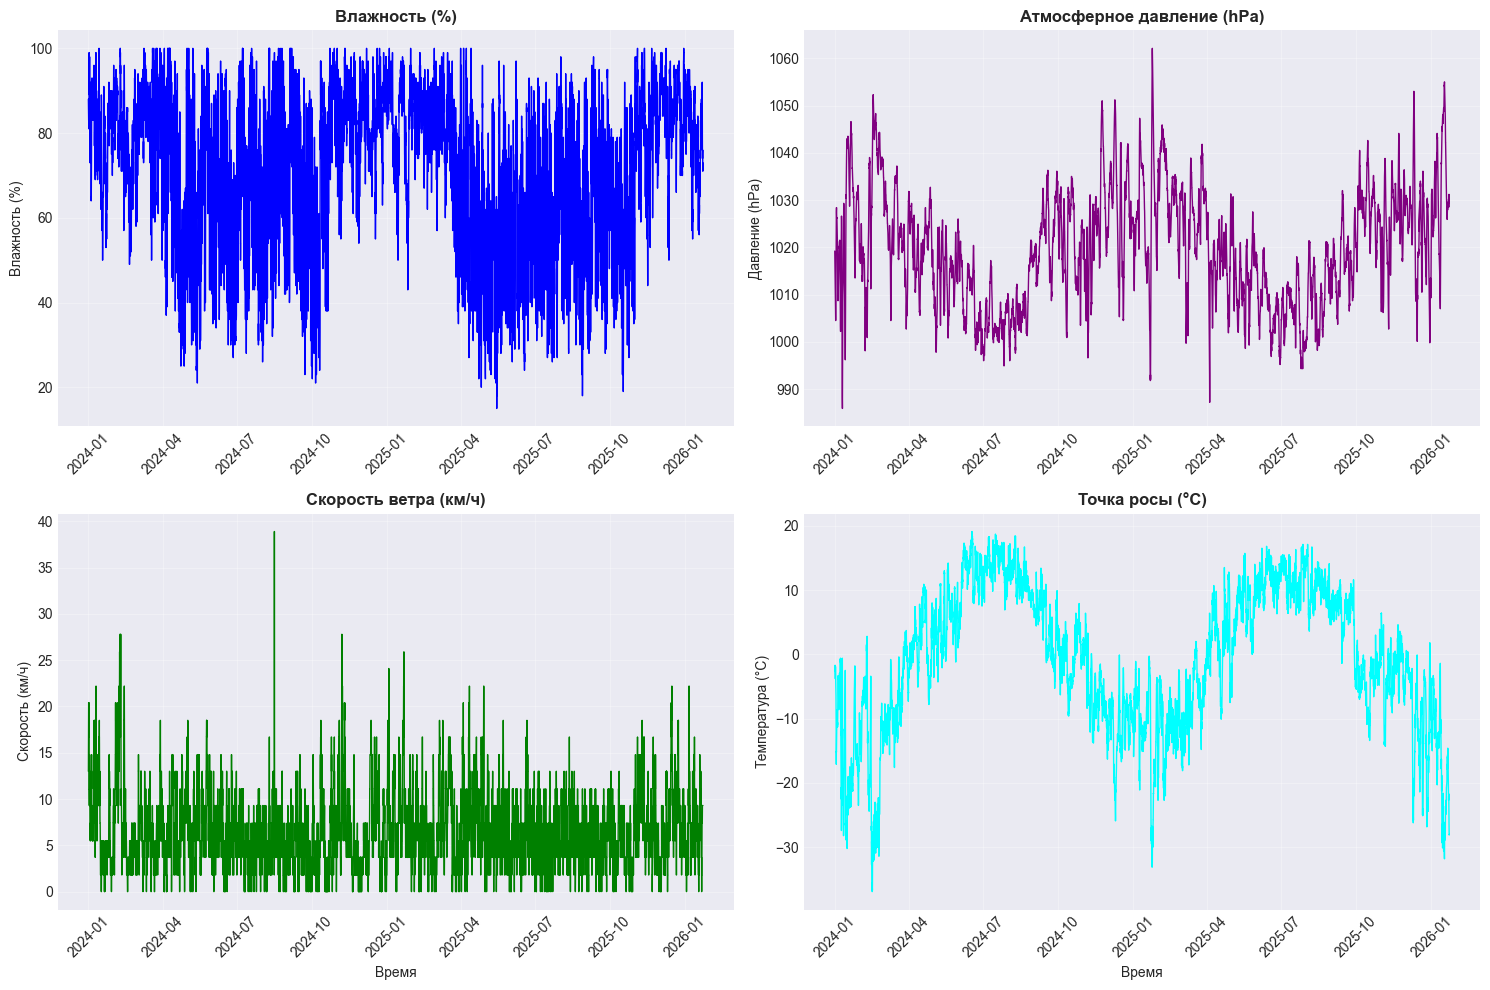

✅ Анализ параметров завершён


In [18]:
# Многопараметровый график
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Влажность
axes[0, 0].plot(df['time'], df['humidity'], color='blue', linewidth=1)
axes[0, 0].set_title('Влажность (%)', fontweight='bold')
axes[0, 0].set_ylabel('Влажность (%)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Давление
axes[0, 1].plot(df['time'], df['pressure'], color='purple', linewidth=1)
axes[0, 1].set_title('Атмосферное давление (hPa)', fontweight='bold')
axes[0, 1].set_ylabel('Давление (hPa)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Скорость ветра
axes[1, 0].plot(df['time'], df['wind_speed'], color='green', linewidth=1)
axes[1, 0].set_title('Скорость ветра (км/ч)', fontweight='bold')
axes[1, 0].set_ylabel('Скорость (км/ч)')
axes[1, 0].set_xlabel('Время')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Точка росы
axes[1, 1].plot(df['time'], df['dew_point'], color='cyan', linewidth=1)
axes[1, 1].set_title('Точка росы (°C)', fontweight='bold')
axes[1, 1].set_ylabel('Температура (°C)')
axes[1, 1].set_xlabel('Время')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/weather_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Анализ параметров завершён")



✅ Временные колонки созданы
   Месяцы: от 1 до 12
   Часы: от 0 до 23


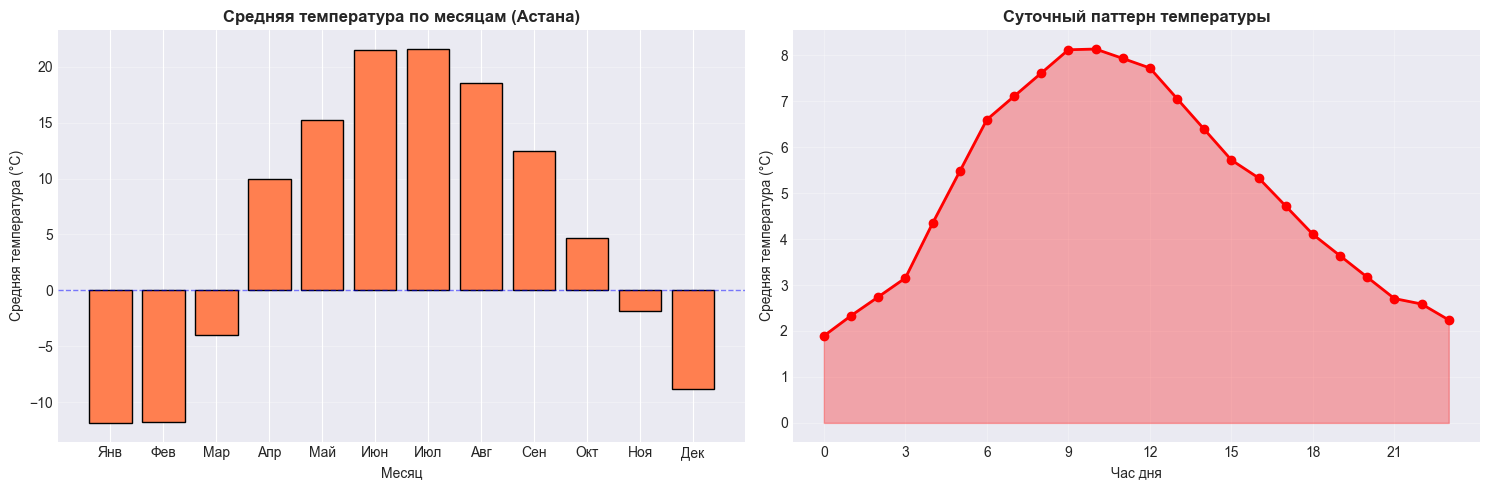

✅ Сезонный анализ завершён
   График сохранён: docs/seasonal_patterns.png


In [19]:
# Сезонный анализ температуры
import pandas as pd
import matplotlib.pyplot as plt

# Убедиться, что time — datetime (важно для Pylance!)
df['time'] = pd.to_datetime(df['time'])

# Извлечь временные компоненты
df['month'] = df['time'].dt.month # type: ignore
df['hour'] = df['time'].dt.hour # type: ignore
df['day_of_year'] = df['time'].dt.dayofyear # type: ignore

print(f"✅ Временные колонки созданы")
print(f"   Месяцы: от {df['month'].min()} до {df['month'].max()}")
print(f"   Часы: от {df['hour'].min()} до {df['hour'].max()}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Средняя температура по месяцам
monthly_temp = df.groupby('month')['temperature'].mean()
axes[0].bar(range(1, 13), monthly_temp, color='coral', edgecolor='black')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя температура (°C)')
axes[0].set_title('Средняя температура по месяцам (Астана)', fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='blue', linestyle='--', linewidth=1, alpha=0.5)

# График 2: Суточный паттерн
hourly_temp = df.groupby('hour')['temperature'].mean()
axes[1].plot(range(24), hourly_temp, marker='o', linewidth=2, markersize=6, color='red')
axes[1].fill_between(range(24), hourly_temp, alpha=0.3, color='red')
axes[1].set_xlabel('Час дня')
axes[1].set_ylabel('Средняя температура (°C)')
axes[1].set_title('Суточный паттерн температуры', fontweight='bold')
axes[1].set_xticks(range(0, 24, 3))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сезонный анализ завершён")
print(f"   График сохранён: docs/seasonal_patterns.png")

